<a href="https://colab.research.google.com/github/gevorgalaverdyan/Multimodal-Bird-Species-Classification/blob/master/Multimodal_Bird_Species_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [27]:
import kagglehub

# Download latest version
bird_images_path = kagglehub.dataset_download("wenewone/cub2002011")

bird_spectrograms_path = kagglehub.dataset_download("gevorgalaverdyan/bird-species-audio-spectrograms-cub-200-aligned")

print("Path to IMAGES dataset files:", bird_images_path)
print("Path to Sdataset files:", bird_spectrograms_path)

Using Colab cache for faster access to the 'cub2002011' dataset.
Using Colab cache for faster access to the 'bird-species-audio-spectrograms-cub-200-aligned' dataset.
Path to IMAGES dataset files: /kaggle/input/cub2002011
Path to Sdataset files: /kaggle/input/bird-species-audio-spectrograms-cub-200-aligned


In [28]:
def show_tree(root, max_depth=2, max_items=10):
    for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath.replace(root, "").count(os.sep)
        if depth >= max_depth:
            dirnames.clear()   # don't go deeper
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath)}/")
        # Show a few files at this level
        for f in filenames[:max_items]:
            print(f"{indent}  {f}")
        if len(filenames) > max_items:
            print(f"{indent}  ... ({len(filenames) - max_items} more files)")

print("=== CUB IMAGE DATASET ===")
show_tree(bird_images_path)

print("\n=== SPECTROGRAM DATASET ===")
show_tree(bird_spectrograms_path)

=== CUB IMAGE DATASET ===
cub2002011/
  cvpr2016_cub/
    vocab_c10.t7
    trainclasses.txt
    manifest.txt
    valids.txt
    allclasses.txt
    testclasses.txt
    trainvalclasses.txt
    trainvalids.txt
    valclasses.txt
    trainids.txt
  CUB_200_2011/
    images.txt
    train_test_split.txt
    image_class_labels.txt
    README
    classes.txt
    bounding_boxes.txt
  segmentations/

=== SPECTROGRAM DATASET ===
bird-species-audio-spectrograms-cub-200-aligned/
  README.md
  metadata.csv
  spectrograms/


Parsing the CUB-200 images

In [29]:
CUB_ROOT  = Path(f"{bird_images_path}/CUB_200_2011")
SPEC_ROOT = Path(bird_spectrograms_path)


# Each file is space-separated with no header
df_images = pd.read_csv(CUB_ROOT / "images.txt",
                        sep=" ", header=None, names=["image_id", "file_path"])

df_labels = pd.read_csv(CUB_ROOT / "image_class_labels.txt",
                        sep=" ", header=None, names=["image_id", "class_id"])

df_split  = pd.read_csv(CUB_ROOT / "train_test_split.txt",
                        sep=" ", header=None, names=["image_id", "is_train"])

df_classes = pd.read_csv(CUB_ROOT / "classes.txt",
                         sep=" ", header=None, names=["class_id", "class_name"])

# Merge everything into one big table
cub_df = (df_images
          .merge(df_labels,  on="image_id")
          .merge(df_split,   on="image_id")
          .merge(df_classes, on="class_id"))

print("CUB dataframe shape:", cub_df.shape)
print(f"Total classes : {cub_df['class_id'].nunique()}")
print(f"Train samples : {cub_df['is_train'].sum()}")
print(f"Test samples  : {(cub_df['is_train']==0).sum()}")
print()
print(cub_df.head(3))

CUB dataframe shape: (11788, 5)
Total classes : 200
Train samples : 5994
Test samples  : 5794

   image_id                                          file_path  class_id  \
0         1  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
1         2  001.Black_footed_Albatross/Black_Footed_Albatr...         1   
2         3  001.Black_footed_Albatross/Black_Footed_Albatr...         1   

   is_train                  class_name  
0         0  001.Black_footed_Albatross  
1         1  001.Black_footed_Albatross  
2         0  001.Black_footed_Albatross  


Parsing Bird Species Audio Spectrograms

In [30]:
spec_meta = pd.read_csv(SPEC_ROOT / "metadata.csv")

print("Spectrogram dataframe shape:", spec_meta.shape)
print(f"Classes with data: {spec_meta['class_id'].nunique()}")
print()
print(spec_meta.head(3))
print()
print("Columns:", spec_meta.columns.tolist())

Spectrogram dataframe shape: (10553, 5)
Classes with data: 199

                                           file_path  class_id  \
0  001.Black_footed_Albatross/Black_footed_Albatr...         1   
1  001.Black_footed_Albatross/Black_footed_Albatr...         1   
2  001.Black_footed_Albatross/Black_footed_Albatr...         1   

                  species                       image_id  segment_number  
0  Black footed Albatross  Black_footed_Albatross_116349               0  
1  Black footed Albatross  Black_footed_Albatross_116349               1  
2  Black footed Albatross  Black_footed_Albatross_116357               0  

Columns: ['file_path', 'class_id', 'species', 'image_id', 'segment_number']


In [31]:
cub_classes  = set(cub_df["class_id"].unique())
spec_classes = set(spec_meta["class_id"].unique())
shared       = sorted(cub_classes & spec_classes)

print(f"CUB classes        : {len(cub_classes)}")
print(f"Spectrogram classes: {len(spec_classes)}")
print(f"Shared classes     : {len(shared)}")
print(f"Dropped            : {len(cub_classes - spec_classes)} classes have no audio")

# Filter both dataframes to shared classes only
cub_df    = cub_df[cub_df["class_id"].isin(shared)].copy()
spec_meta = spec_meta[spec_meta["class_id"].isin(shared)].copy()

# Build the remapping: class_id (1-200) → label (0-based index)
class_to_label = {cid: idx for idx, cid in enumerate(shared)}
NUM_CLASSES    = len(shared)

cub_df["label"]    = cub_df["class_id"].map(class_to_label)
spec_meta["label"] = spec_meta["class_id"].map(class_to_label)

print(f"\nNUM_CLASSES = {NUM_CLASSES}  (labels 0 – {NUM_CLASSES-1})")
print(f"CUB rows kept   : {len(cub_df)}")
print(f"Spec rows kept  : {len(spec_meta)}")

CUB classes        : 200
Spectrogram classes: 199
Shared classes     : 199
Dropped            : 1 classes have no audio

NUM_CLASSES = 199  (labels 0 – 198)
CUB rows kept   : 11730
Spec rows kept  : 10553


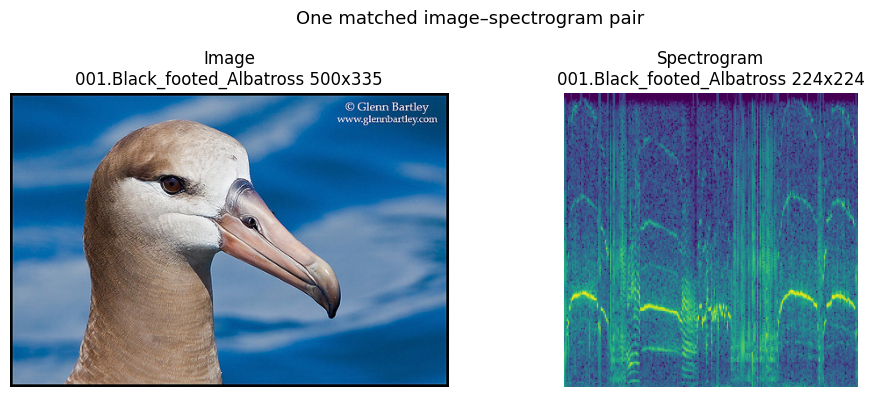

If both images loaded above, paths are correct


In [32]:
# Pick a sample row from CUB
sample_row  = cub_df.iloc[0]
img_path    = CUB_ROOT / "images" / sample_row["file_path"]

# Pick a matching spectrogram (same class)
label       = sample_row["label"]
spec_row    = spec_meta[spec_meta["label"] == label].iloc[0]
spec_path   = SPEC_ROOT / "spectrograms" / spec_row["file_path"]

img = Image.open(img_path)
spec = Image.open(spec_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
axes[0].set_title(f"Image\n{sample_row['class_name']} {img.size[0]}x{img.size[1]}")
axes[0].axis("off")

axes[1].imshow(spec)
axes[1].set_title(f"Spectrogram\n{sample_row['class_name']} {spec.size[0]}x{spec.size[1]}")
axes[1].axis("off")

plt.suptitle("One matched image–spectrogram pair", fontsize=13)
plt.tight_layout()
plt.show()

print("If both images loaded above, paths are correct")

In [33]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms defined")

Transforms defined


In [35]:
class MultimodalBirdDataset(Dataset):
    def __init__(self, cub_df, spec_df, cub_root, spec_root,
                 img_transform=None, spec_transform=None):

        # ── Guard clauses — catch missing columns immediately ──
        assert "label" in cub_df.columns, (
            "cub_df is missing the 'label' column. "
            "Re-run Cell 9 (the class remapping cell) before creating the dataset."
        )
        assert "label" in spec_df.columns, (
            "spec_df is missing the 'label' column. "
            "Re-run Cell 9 (the class remapping cell) before creating the dataset."
        )

        # reset_index is critical — without it iloc[i] can return a row
        # whose pandas index is not i, causing subtle lookup bugs
        self.cub_df         = cub_df.reset_index(drop=True)
        self.cub_root       = Path(cub_root)
        self.spec_root      = Path(spec_root)
        self.img_transform  = img_transform
        self.spec_transform = spec_transform

        self.spec_by_label = (
            spec_df.groupby("label")["file_path"]
            .apply(list)
            .to_dict()
        )

    def __len__(self):
        return len(self.cub_df)

    def __getitem__(self, idx):
        row   = self.cub_df.iloc[idx]
        label = int(row["label"])

        img_path = self.cub_root / "images" / row["file_path"]
        image    = Image.open(img_path).convert("RGB")
        if self.img_transform:
            image = self.img_transform(image)

        spec_path = self.spec_root / "spectrograms" / random.choice(self.spec_by_label[label])
        spec      = Image.open(spec_path).convert("RGB")
        if self.spec_transform:
            spec = self.spec_transform(spec)

        return image, spec, label


# Build train/test splits
train_ds = MultimodalBirdDataset(
    cub_df[cub_df["is_train"] == 1], spec_meta,
    CUB_ROOT, SPEC_ROOT,
    img_transform=train_transform, spec_transform=train_transform,
)
test_ds = MultimodalBirdDataset(
    cub_df[cub_df["is_train"] == 0], spec_meta,
    CUB_ROOT, SPEC_ROOT,
    img_transform=val_transform, spec_transform=val_transform,
)

BATCH_SIZE   = 16   # lower to 8 if you get CUDA out-of-memory errors
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verify one batch loads correctly
imgs, specs, labels = next(iter(train_loader))
print(f"Image tensor  : {imgs.shape}")    # [16, 3, 224, 224]
print(f"Spec tensor   : {specs.shape}")   # [16, 3, 224, 224]
print(f"Labels        : {labels.shape}")  # [16]
print(f"Label range   : {labels.min().item()} – {labels.max().item()}")

Image tensor  : torch.Size([16, 3, 224, 224])
Spec tensor   : torch.Size([16, 3, 224, 224])
Labels        : torch.Size([16])
Label range   : 2 – 198


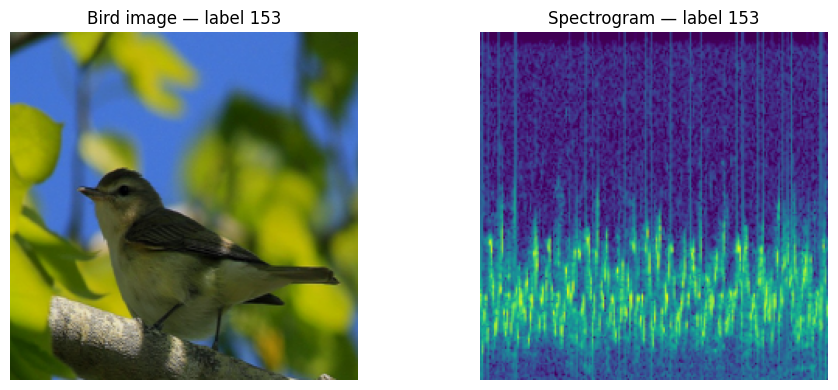

In [51]:
def unnormalise(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

imgs, specs, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(unnormalise(imgs[0]).permute(1,2,0))
axes[0].set_title(f"Bird image — label {labels[0].item()}")
axes[0].axis("off")
axes[1].imshow(unnormalise(specs[0]).permute(1,2,0))
axes[1].set_title(f"Spectrogram — label {labels[0].item()}")
axes[1].axis("off")
plt.tight_layout()
plt.show()